# 1. One network, one error bar

This notebook sets up the problem the next three notebooks build on. It:

1. introduces `toy1d`, the 1-D problem used for debugging throughout,
2. trains a network that predicts its own observation noise,
3. defines the metrics that say whether an error bar is "honest",
4. runs the same model on your own application and saves the result.

You write one function here, `calibration_error`. The rest is provided, because
this notebook is where the vocabulary gets set up.

## 1.1 The problem

`toy1d` is 1-D regression with two sources of uncertainty built in on purpose:

* a gap in the training inputs, roughly `-0.5 < x < 1.5`, with no data at all;
* noise that grows with `x`, so the scatter on the right is larger than on the left.

They stand for the two kinds of uncertainty. The gap is "epistemic": it would go
away if someone gave you more data. The noise is "aleatoric": it would not, because it is inherent to the data

The test set is drawn from the same distribution as the training set, gap
excluded, so test metrics measure what they claim to. The shifted set is the gap
plus everything beyond the training range.

In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import torch

from bdl.data import (
    load_track,
    make_toy1d,
    split_fingerprint,
    toy1d_grid,
    toy1d_noise_std,
    toy1d_truth,
)
from bdl.metrics import auroc, interval_coverage, predictive_nll, results_table, rmse
from bdl.models import (
    build_model,
    count_parameters,
    default_loss,
    fit,
    gaussian_head,
    set_seed,
    track_hparams,
)
from bdl.plots import plot_band, plot_reliability
from bdl.store import run_dir, save_run

%matplotlib inline
print("torch", torch.__version__)

torch 2.13.0


Dataset(toy1d, task=regression, train=(200, 1), test=(400, 1), ood=(198, 1), n_outputs=1)
split fingerprint: 21ab344b183a  (should be 21ab344b183a)


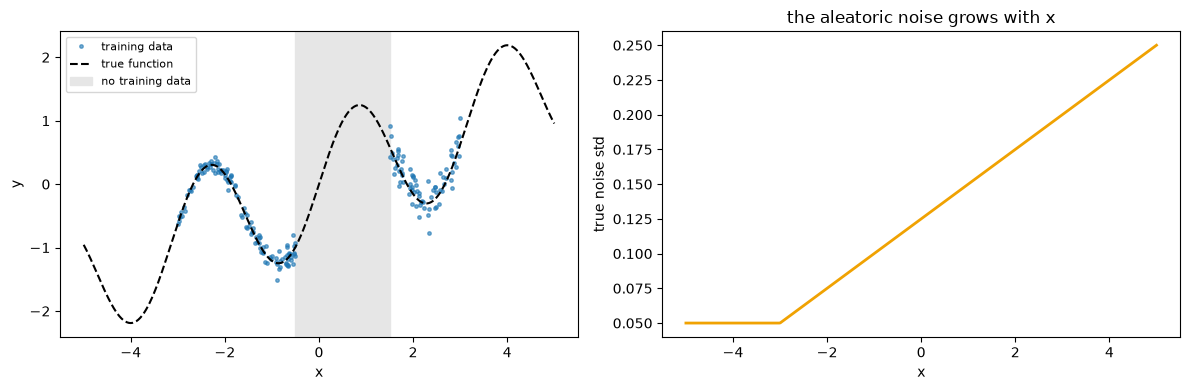

In [2]:
ds = make_toy1d()
print(ds)
print("split fingerprint:", split_fingerprint(ds), " (should be 21ab344b183a)")

grid = toy1d_grid()  # a dense grid for plotting
g = grid.numpy().ravel()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ds.x_train, ds.y_train, ".", ms=5, alpha=0.6, label="training data")
ax1.plot(g, toy1d_truth(g), "k--", lw=1.5, label="true function")
ax1.axvspan(-0.5, 1.5, color="0.9", zorder=0, label="no training data")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend(fontsize=8)
ax2.plot(g, toy1d_noise_std(g), lw=2, color="#f0a202")
ax2.set_xlabel("x")
ax2.set_ylabel("true noise std")
ax2.set_title("the aleatoric noise grows with x")
plt.tight_layout()

## 1.2 A network that predicts its own noise

The network has two outputs per input: an expected value of the function and the log variance of the expected value. Hereafter these are referred to as `mu(x)` (measured value of this is called y in the plot above) and `log sigma^2(x)`. It is trained on the Gaussian negative log-likelihood

    -log p(y | x, W) = 0.5 log(2 pi sigma^2(x)) + (y - mu(x))^2 / (2 sigma^2(x))

rather than on squared error (can you asnwer why?). 
Letting the network predict `sigma(x)` is what produces an aleatoric estimate.

Two provided functions do this: `gaussian_nll_loss` is the line above, and
`gaussian_head` turns the two raw outputs into `(mu, sigma)`. The log-variance is
clamped to `[-8, 4]`, which keeps `sigma` in `[0.018, 7.39]` and stops a point
that is fitted exactly from driving the gradient to infinity.

In [3]:
set_seed(0)
model = build_model(ds, hidden=(64, 64))  # two outputs, because ds.task == "regression"
print(model)
print("trainable parameters:", count_parameters(model))

history = fit(
    model,
    ds.x_train,
    ds.y_train,
    loss_fn=default_loss(ds),  # gaussian_nll_loss for a regression track
    epochs=400,
    lr=1e-2,
    seed=0,
)
print(f"final training loss: {history[-1]:.4f}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
trainable parameters: 4418
final training loss: -0.6117


## 1.3 Predictions carry a sample axis

Every method in this project answers the same question in the same format: give
me `S` plausible versions of the predictive distribution at these `N` inputs. For
regression that is two arrays,

    mu    [S, N]    the mean predicted by sampled network s at input n
    sigma [S, N]    the observation noise that same network predicts

The `S` axis is what separates the two uncertainties. Aleatoric uncertainty is
inside each sample: it is `sigma`. Epistemic uncertainty is the disagreement
between samples. Keep the axis until the last moment.

A deterministic network is the case `S = 1`.

In [4]:
@torch.no_grad()
def predict_deterministic(model, x):
    """One forward pass, returned with a sample axis of length 1."""
    model.eval()
    mu, sigma = gaussian_head(model(x))
    return mu.unsqueeze(0), sigma.unsqueeze(0)  # [1, N] each


mu_grid, sd_grid = predict_deterministic(model, grid)
print("mu   ", tuple(mu_grid.shape))
print("sigma", tuple(sd_grid.shape))

mu    (1, 500)
sigma (1, 500)


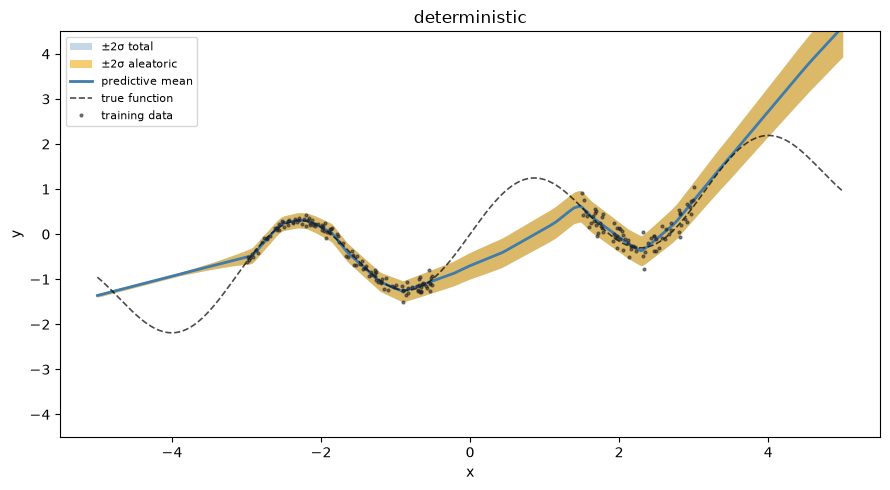

In [6]:
# The predictive mean and the aleatoric standard deviation, on the plotting grid.
# With S = 1 the total width and the aleatoric width are the same thing, so both
# bands in this figure coincide. Notebook 02 is where they come apart.
mean = mu_grid.mean(0)
sd_aleatoric = (sd_grid**2).mean(0).sqrt()

fig, ax = plt.subplots(figsize=(9, 5))
plot_band(ax, grid, mean, sd_aleatoric, sd_aleatoric, ds=ds, title="deterministic")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()

## 1.4 What this model cannot do

Look at the band inside the gap and beyond the training range. It is narrow, and
the mean continues in a straight line. The model has no data there but the uncertainty is still low.

In [9]:
print("S =", mu_grid.shape[0])
print("largest difference between sampled means:", float((mu_grid - mu_grid[0]).abs().max()))
print()
print("Repeated calls return the same numbers, so this model's disagreement with")
print("itself is exactly zero, everywhere, including where it is wrong.")

S = 1
largest difference between sampled means: 0.0

Repeated calls return the same numbers, so this model's disagreement with
itself is exactly zero, everywhere, including where it is wrong.


## 1.5 Measuring whether an error bar is unrealistic!

Three numbers, answering three different questions.

**Negative log predictive density (NLL).** How probable was the observed `y`
under the predicted distribution. The predictive is a mixture of the `S` sampled
Gaussians,

    p(y | x) = (1/S) sum_s N(y; mu_s, sigma_s^2)

so its log needs a log-sum-exp rather than an average of log densities. Provided
as `predictive_nll`. Unlike RMSE it punishes confident wrongness, and unlike the
calibration error below it also punishes ordinary wrongness.

**Interval coverage.** For a nominal central level `q`, the fraction of test
points that land inside the model's central-`q` predictive interval. A calibrated
model returns about `q`; less means the error bars are too tight. Provided as
`interval_coverage`, which bisects the exact mixture CDF.

**Calibration error.** One number summarising coverage across levels:

    ECE = mean over q of | empirical coverage(q) - q |

That one is yours. Use `n_bins` levels evenly spaced strictly inside `(0, 1)`,
which `torch.linspace(0.0, 1.0, n_bins + 2)[1:-1]` gives you, and
`interval_coverage` for each level.

Two things this number does not see. It is two-sided, so an underconfident model
is penalised as much as an overconfident one. And it does not care which side of
the interval the misses fall on, so a model with a biased mean and generous error
bars can still score well. Report RMSE next to it.

In [ ]:
def calibration_error(mu, sigma, y, n_bins=15):
    """Mean absolute gap between nominal credible level and empirical coverage.

    mu, sigma : [S, N]
    y         : [N] or [N, 1]

    Returns one float. 0 means the stated intervals are exactly right.
    """
    # ---- TODO ------------------------------------------------------------
    # 1. build n_bins levels strictly inside (0, 1)
    # 2. for each level q, compare interval_coverage(mu, sigma, y, q) with q
    # 3. return the mean of the absolute differences
    raise NotImplementedError
    # ----------------------------------------------------------------------

In [ ]:
# ---- check your work -------------------------------------------------------
torch.manual_seed(0)

# 1. A predictive that tells the truth: the targets really are drawn from
#    N(0, 2^2), so coverage matches every nominal level and the error is ~0.
n = 20_000
truthful_mu = torch.zeros(1, n)
truthful_sd = torch.full((1, n), 2.0)
y_truthful = torch.randn(n) * 2.0
ece_truthful = calibration_error(truthful_mu, truthful_sd, y_truthful)
assert ece_truthful < 0.02, f"a calibrated model should score about 0, got {ece_truthful:.4f}"

# 2. Error bars ten times too tight: the intervals contain almost nothing, so
#    every gap is roughly the nominal level itself and the mean is about 0.5.
ece_tight = calibration_error(torch.zeros(1, 5000), torch.full((1, 5000), 0.1), torch.randn(5000))
assert ece_tight > 0.4, f"an overconfident model should score above 0.4, got {ece_tight:.4f}"

# 3. And the helper you built on agrees with its nominal level.
cov = interval_coverage(truthful_mu, truthful_sd, y_truthful, 0.95)
assert abs(cov - 0.95) < 0.02, cov

print(f"OK   truthful {ece_truthful:.4f}   too tight {ece_tight:.4f}   coverage@95 {cov:.3f}")

## 1.6 The baseline, scored

Now put the three metrics on the test set and on the shifted set. Two entries in
the table are filled in by hand rather than computed, and the reason is section
1.4: with `S = 1` the epistemic term is zero by construction, so every point gets
the same out-of-distribution score.

In [ ]:
mu_id, sd_id = predict_deterministic(model, ds.x_test)
mu_ood, sd_ood = predict_deterministic(model, ds.x_ood)

# Every point scores the same, because the score is the disagreement between
# sampled networks and there is only one network.
score_id = torch.zeros(mu_id.shape[1])
score_ood = torch.zeros(mu_ood.shape[1])

metrics = {
    "nll": predictive_nll(mu_id, sd_id, ds.y_test),
    "rmse": rmse(mu_id, ds.y_test),
    "ece": calibration_error(mu_id, sd_id, ds.y_test),
    "coverage@95": interval_coverage(mu_id, sd_id, ds.y_test, 0.95),
    "aleatoric_id": float((sd_id**2).mean()),
    "epistemic_id": 0.0,
    "epistemic_ood": 0.0,
    "epistemic_ratio": 0.0,
    "ood_auroc": auroc(score_id, score_ood),
    "nll_ood": predictive_nll(mu_ood, sd_ood, ds.y_ood),
}
print(results_table({"deterministic": metrics}))

In [ ]:
levels = np.linspace(0.05, 0.95, 12)
coverage = [interval_coverage(mu_id, sd_id, ds.y_test, float(q)) for q in levels]
plot_reliability({"deterministic": (levels, coverage)});

## 1.7 Two things to be able to explain

**The OOD AUROC is exactly 0.500.** Not approximately. `auroc` is a rank
statistic, and when every point carries the same score every pair is a tie, which
scores half. This is arithmetic, not a measurement, so do not report it as a
finding about the method.

**The shifted NLL is in the hundreds while the test NLL is negative.** Per point
the NLL is `0.5 log(2 pi sigma^2) + delta^2 / (2 sigma^2)`. Put in the `sigma`
this model reports on the shifted set and the residuals `delta` it actually
makes, and you get the number in the table. On this data the reported `sigma`
does not grow away from the training range; on some tracks it shrinks.

Both facts have one cause: there is no term in this predictive distribution that
can grow when the input is unfamiliar. That is what the next three notebooks add.

## 1.8 Your own track

Everything from here on is the same code with a different dataset. Pick one track
and keep it for the whole project.

| | Track A, astrophysics | Track B, chemistry | Track C, biology / imaging |
|---|---|---|---|
| data | Pantheon+ Type Ia supernovae, 1624 objects, 5 features | ESOL aqueous solubility, 1128 molecules, 6 descriptors | MedMNIST blood cells, 8 classes, 28x28 RGB |
| predict | peak apparent brightness, in magnitudes | log solubility, in mol/L | cell type |
| shift | supernovae more distant than any in training, `z > 0.5` | molecules heavier than any in training | the same images with sensor noise |
| task | regression | regression | classification |

Set `TRACK` below. Per-track training settings come from `track_hparams`, so
there is nothing to tune: Track C needs fewer epochs and a smaller learning rate
because it has 6000 points and 2352 inputs per point.

Track C is a classification track, so its metrics are accuracy and a binned
confidence calibration rather than RMSE and interval coverage. The cell below
handles both.

In [ ]:
TRACK = "A"  # <-- "A", "B" or "C"

ds_track = load_track(TRACK)
hp = track_hparams(TRACK, "deterministic")
print(ds_track)
print("split fingerprint:", split_fingerprint(ds_track))
print("hyperparameters:", hp)

In [ ]:
import time

t0 = time.perf_counter()
set_seed(0)
model_track = build_model(ds_track, hidden=(64, 64))
fit(
    model_track,
    ds_track.x_train,
    ds_track.y_train,
    loss_fn=default_loss(ds_track),
    epochs=int(hp["epochs"]),
    lr=hp["lr"],
    seed=0,
)
train_s = time.perf_counter() - t0
print(f"trained in {train_s:.1f}s")

In [ ]:
if ds_track.task == "regression":
    mu_t, sd_t = predict_deterministic(model_track, ds_track.x_test)
    mu_to, sd_to = predict_deterministic(model_track, ds_track.x_ood)
    row = {
        "nll": predictive_nll(mu_t, sd_t, ds_track.y_test),
        "rmse": rmse(mu_t, ds_track.y_test),
        "ece": calibration_error(mu_t, sd_t, ds_track.y_test),
        "coverage@95": interval_coverage(mu_t, sd_t, ds_track.y_test, 0.95),
        "aleatoric_id": float((sd_t**2).mean()),
        "nll_ood": predictive_nll(mu_to, sd_to, ds_track.y_ood),
    }
    arrays = {}
else:
    # Classification: one forward pass gives one categorical distribution, again
    # with a sample axis of length 1.
    from bdl.metrics import accuracy, predictive_nll_probs

    with torch.no_grad():
        model_track.eval()
        probs_t = torch.softmax(model_track(ds_track.x_test), dim=-1).unsqueeze(0)
    row = {
        "nll": predictive_nll_probs(probs_t, ds_track.y_test),
        "accuracy": accuracy(probs_t, ds_track.y_test),
        # Your calibration_error is the regression one; Track C needs the binned
        # classification version, which you write in notebook 02.
    }
    arrays = {}

row |= {"epistemic_id": 0.0, "epistemic_ood": 0.0, "epistemic_ratio": 0.0, "ood_auroc": 0.5}
row["train_s"] = round(train_s, 2)
print(results_table({"deterministic": row}))
save_run(TRACK, "deterministic", row, **arrays)

In [ ]:
# Save the toy1d numbers and curves too, so notebook 05 can draw the comparison
# figures without retraining anything.
save_run(
    "toy1d",
    "deterministic",
    metrics | {"train_s": 0.0},
    mean=mean,
    sd_aleatoric=sd_aleatoric,
    sd_total=sd_aleatoric,
    epistemic_std=torch.zeros_like(sd_aleatoric),
    levels=levels,
    coverage=np.array(coverage),
)
print("results directory:", run_dir("toy1d"))

## Done when

* the check cell in 1.5 prints `OK`;
* your toy1d table matches the shape of the discussion in 1.7: negative test NLL,
  an OOD AUROC of exactly 0.5, and a shifted NLL two or three orders of magnitude
  larger than the test NLL;
* `results/toy1d/deterministic.json` and `results/<your track>/deterministic.json`
  both exist.

Next: notebook 02 gets a second set of weights, and with it the first honest
epistemic uncertainty.